In [9]:
!pip install pandas matplotlib seaborn

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('Superstore_Dataset.csv')

In [45]:
print("First 5 rows of the dataset")
print(df.head())

First 5 rows of the dataset
    Order ID  Order Date       Ship Mode Customer Name      Segment Country  \
0  CA-001001  2022-01-01  Standard Class          Ravi  Home Office   India   
1  CA-001002  2022-01-02        Same Day           Ram  Home Office   India   
2  CA-001003  2022-01-03     First Class           Ram     Consumer   India   
3  CA-001004  2022-01-04  Standard Class        Anjali     Consumer   India   
4  CA-001005  2022-01-05  Standard Class           Ram    Corporate   India   

    Region    Category Sub-Category   Sales  Quantity  Discount  Profit  
0    South  Technology       Tables  690.28         3      0.07 -199.18  
1    South  Technology  Accessories  623.53         7      0.20 -107.56  
2  Central   Furniture        Paper  945.01         3      0.19 -359.33  
3    South   Furniture  Accessories  945.37         2      0.11  369.19  
4  Central  Technology       Tables  869.85         4      0.03   81.41  


In [46]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       100 non-null    object 
 1   Order Date     100 non-null    object 
 2   Ship Mode      100 non-null    object 
 3   Customer Name  100 non-null    object 
 4   Segment        100 non-null    object 
 5   Country        100 non-null    object 
 6   Region         100 non-null    object 
 7   Category       100 non-null    object 
 8   Sub-Category   100 non-null    object 
 9   Sales          100 non-null    float64
 10  Quantity       100 non-null    int64  
 11  Discount       100 non-null    float64
 12  Profit         100 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 10.3+ KB
None


In [47]:
print(df.isnull().sum())

Order ID         0
Order Date       0
Ship Mode        0
Customer Name    0
Segment          0
Country          0
Region           0
Category         0
Sub-Category     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [49]:
print(df.describe(include='all'))

         Order ID  Order Date Ship Mode Customer Name   Segment Country  \
count         100         100       100           100       100     100   
unique        100         100         4             8         3       1   
top     CA-001001  2022-01-01  Same Day          Ravi  Consumer   India   
freq            1           1        30            18        36     100   
mean          NaN         NaN       NaN           NaN       NaN     NaN   
std           NaN         NaN       NaN           NaN       NaN     NaN   
min           NaN         NaN       NaN           NaN       NaN     NaN   
25%           NaN         NaN       NaN           NaN       NaN     NaN   
50%           NaN         NaN       NaN           NaN       NaN     NaN   
75%           NaN         NaN       NaN           NaN       NaN     NaN   
max           NaN         NaN       NaN           NaN       NaN     NaN   

       Region    Category Sub-Category       Sales    Quantity    Discount  \
count     100        

In [16]:
print("\nUnique Region:",df['Region'].unique())
print("\nUnique Categories:",df['Category'].unique())


Unique Region: ['South' 'Central' 'West' 'East']

Unique Categories: ['Technology' 'Furniture' 'Office Supplies']


In [17]:
print("\nTotal sales by Region:")
print(df.groupby('Region')['Sales'].sum())
print("\nTotal sales by Category:")
print(df.groupby('Category')['Sales'].sum())
print("\nTotal sales by Segment:")
print(df.groupby('Segment')['Sales'].sum())



Total sales by Region:
Region
Central    12493.43
East       12618.93
South      20168.55
West       10702.09
Name: Sales, dtype: float64

Total sales by Category:
Category
Furniture          17553.59
Office Supplies    19206.05
Technology         19223.36
Name: Sales, dtype: float64

Total sales by Segment:
Segment
Consumer       19055.40
Corporate      18767.75
Home Office    18159.85
Name: Sales, dtype: float64


In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


In [23]:
sales_over_time = df.groupby('Order Date')['Sales'].sum()

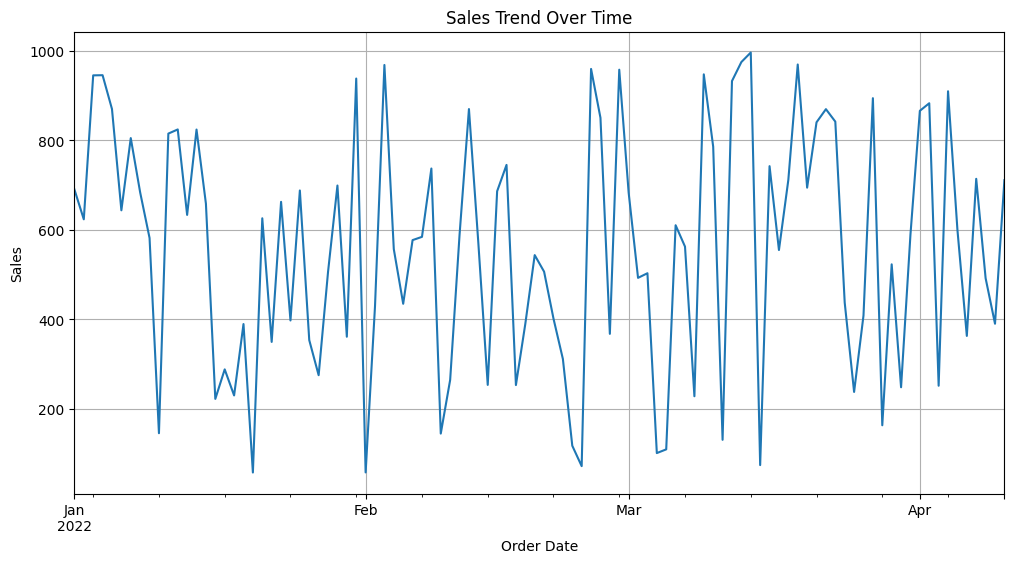

In [24]:
plt.figure(figsize=(12,6))
sales_over_time.plot()
plt.title('Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

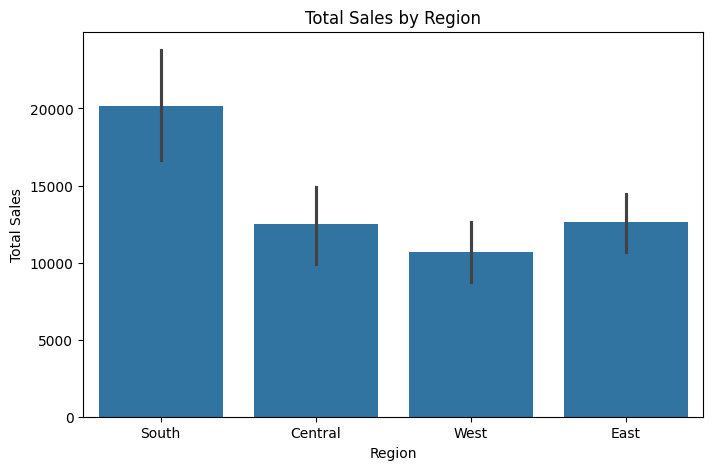

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

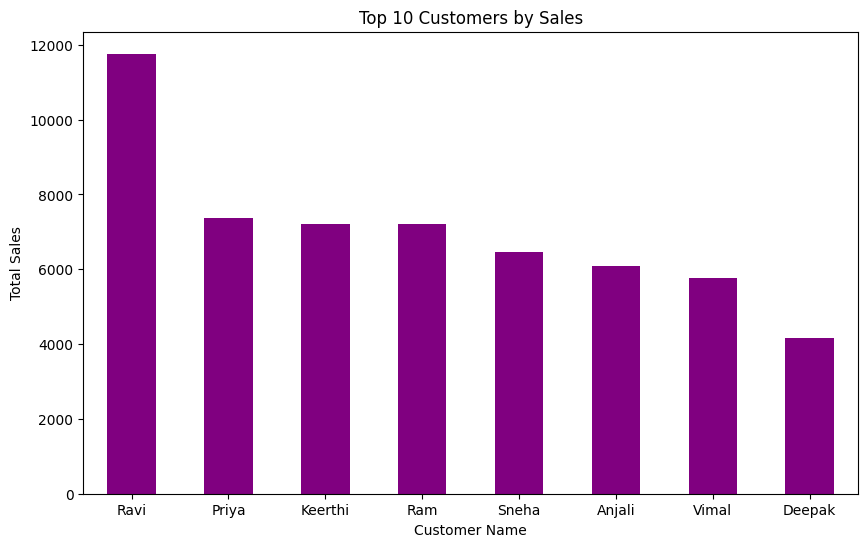

In [40]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_customers.plot(kind='bar',color='Purple')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=360)
plt.show()

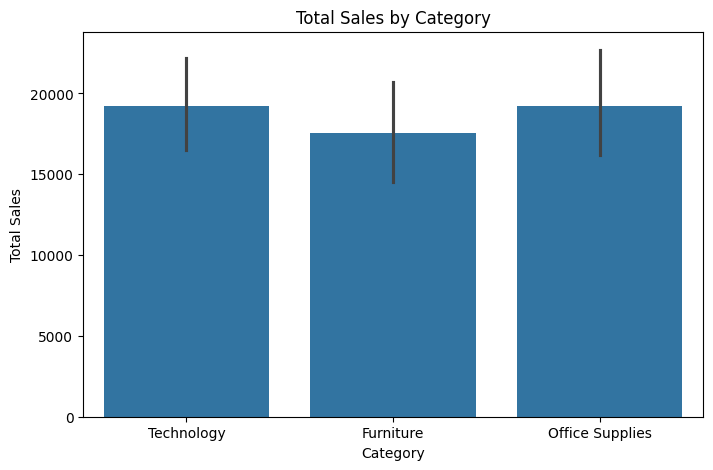

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category',y='Sales',data=df, estimator=sum)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

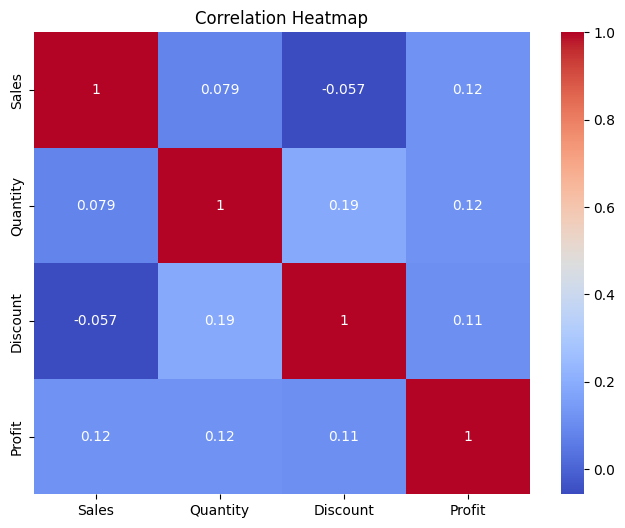

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

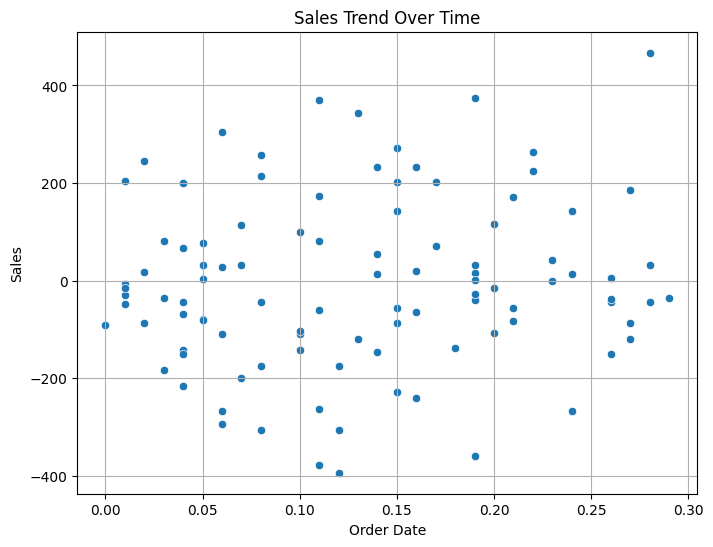

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Discount',y='Profit',data=df)
plt.title('Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

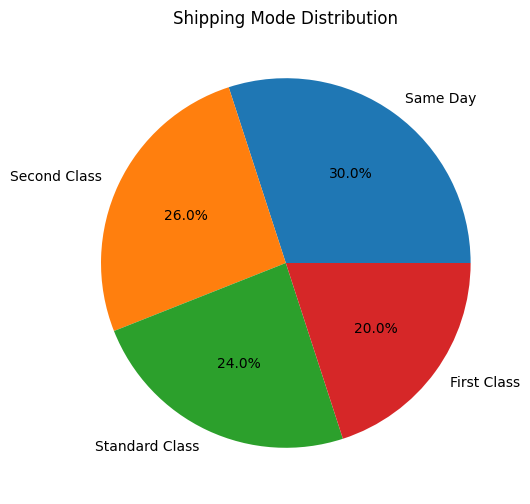

In [34]:
plt.figure(figsize=(6,6))
df['Ship Mode'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Shipping Mode Distribution')
plt.ylabel('')
plt.show()
